In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import silhouette_score
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

c:\Users\David\Documents\4530\ACIT4530\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Input artifact folders from previous steps
step1_dir = Path("./results_step1")
step2_dir = Path("./results_step2")

# New output folder for corrected / strengthened Step 3
step3_dir = Path("./results_step3_v2")
step3_dir.mkdir(parents=True, exist_ok=True)

print("Step 1 input dir:", step1_dir.resolve())
print("Step 2 input dir:", step2_dir.resolve())
print("Step 3 v2 output dir:", step3_dir.resolve())

Step 1 input dir: C:\Users\David\Documents\4530\ACIT4530\David\results_step1
Step 2 input dir: C:\Users\David\Documents\4530\ACIT4530\David\results_step2
Step 3 v2 output dir: C:\Users\David\Documents\4530\ACIT4530\David\results_step3_v2


In [3]:
step1_required_files = [
    "ratings_filtered.parquet",
    "movies.parquet",
    "users.parquet",
    "train_split_model_universe.parquet",
    "validation_split_model_universe.parquet",
    "test_split_model_universe.parquet",
    "step1_config.json",
]

step2_required_files = [
    "user_embeddings_p_u.npy",
    "item_embeddings_q_i.npy",
    "item_bias.npy",
    "user_embeddings_p_u.parquet",
    "item_embeddings_q_i.parquet",
    "user_index_mapping.parquet",
    "item_index_mapping.parquet",
    "final_step2_config.json",
]

def make_required_file_check(base_dir, filenames, source_name):
    rows = []

    for filename in filenames:
        path = base_dir / filename
        rows.append({
            "source": source_name,
            "filename": filename,
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / (1024 ** 2), 4) if path.exists() else np.nan,
        })

    return pd.DataFrame(rows)

required_file_check = pd.concat(
    [
        make_required_file_check(step1_dir, step1_required_files, "step1"),
        make_required_file_check(step2_dir, step2_required_files, "step2"),
    ],
    ignore_index=True,
)

display(required_file_check)

missing_required_files = required_file_check[~required_file_check["exists"]]

if len(missing_required_files) > 0:
    display(missing_required_files)
    raise FileNotFoundError(
        "Missing required Step 1 or Step 2 artifacts. Fix these before continuing Step 3."
    )

print("All required Step 1 and Step 2 artifacts exist.")

,source,filename,exists,size_mb
0,step1,ratings_filtered.parquet,True,8.5200
1,step1,movies.parquet,True,0.0993
2,step1,users.parquet,True,0.0686
3,step1,train_split_model_universe.parquet,True,6.1756
4,step1,validation_split_model_universe.parquet,True,1.0917
5,step1,test_split_model_universe.parquet,True,1.1787
6,step1,step1_config.json,True,0.0006
7,step2,user_embeddings_p_u.npy,True,1.1530
8,step2,item_embeddings_q_i.npy,True,0.7936
9,step2,item_bias.npy,True,0.0125


All required Step 1 and Step 2 artifacts exist.


In [4]:
with open(step1_dir / "step1_config.json", "r") as f:
    step1_config = json.load(f)

with open(step2_dir / "final_step2_config.json", "r") as f:
    step2_config = json.load(f)

random_seed = int(
    step2_config.get(
        "random_seed",
        step1_config.get("random_seed", step1_config.get("seed", 42))
    )
)

random.seed(random_seed)
np.random.seed(random_seed)

config_summary = pd.DataFrame([
    {
        "config": "step1",
        "dataset": step1_config.get("dataset"),
        "random_seed": step1_config.get("random_seed", step1_config.get("seed")),
        "pair_min_diff": step1_config.get("pair_min_diff"),
        "min_user_ratings": step1_config.get("min_user_ratings"),
        "min_movie_ratings": step1_config.get("min_movie_ratings"),
        "split_strategy": step1_config.get("split_strategy"),
    },
    {
        "config": "step2",
        "embedding_dim": step2_config.get("embedding_dim"),
        "n_users": step2_config.get("n_users"),
        "n_items": step2_config.get("n_items"),
        "selection_metric": step2_config.get("selection_metric"),
        "final_experiment_name": step2_config.get("final_experiment_name"),
        "test_used_for_selection": step2_config.get("test_used_for_selection"),
    },
])

display(config_summary)

print("Random seed used in Step 3:", random_seed)

,config,dataset,random_seed,pair_min_diff,min_user_ratings,min_movie_ratings,split_strategy,embedding_dim,n_users,n_items,selection_metric,final_experiment_name,test_used_for_selection
0,step1,MovieLens 1M,42.0,2.0,40.0,10.0,per_user_temporal_split_with_same_timestamp_gr...,NaN,NaN,NaN,NaN,NaN,NaN
1,step2,NaN,NaN,NaN,NaN,NaN,NaN,64.0,4722.0,3250.0,validation_macro_accuracy_best,pair_sampling_gap2_random_cap_dim64_lr3em04_re...,False


Random seed used in Step 3: 42


# 1 Load data, embeddings, mappings

In [5]:
ratings_filtered = pd.read_parquet(step1_dir / "ratings_filtered.parquet")
movies = pd.read_parquet(step1_dir / "movies.parquet")
users = pd.read_parquet(step1_dir / "users.parquet")

train_df = pd.read_parquet(step1_dir / "train_split_model_universe.parquet")
val_df = pd.read_parquet(step1_dir / "validation_split_model_universe.parquet")
test_df = pd.read_parquet(step1_dir / "test_split_model_universe.parquet")

user_embeddings_np = np.load(step2_dir / "user_embeddings_p_u.npy")
item_embeddings_np = np.load(step2_dir / "item_embeddings_q_i.npy")
item_bias_np = np.load(step2_dir / "item_bias.npy").reshape(-1)

user_embeddings_df = (
    pd.read_parquet(step2_dir / "user_embeddings_p_u.parquet")
    .sort_values("user_idx")
    .reset_index(drop=True)
)

item_embeddings_df = (
    pd.read_parquet(step2_dir / "item_embeddings_q_i.parquet")
    .sort_values("item_idx")
    .reset_index(drop=True)
)

user_index_mapping = (
    pd.read_parquet(step2_dir / "user_index_mapping.parquet")
    .sort_values("user_idx")
    .reset_index(drop=True)
)

item_index_mapping = (
    pd.read_parquet(step2_dir / "item_index_mapping.parquet")
    .sort_values("item_idx")
    .reset_index(drop=True)
)

print("Loaded Step 1 and Step 2 artifacts.")

Loaded Step 1 and Step 2 artifacts.


### 1.1 Detect embedding columns robustly

In [6]:
def get_embedding_columns(df, prefix):
    cols = [col for col in df.columns if col.startswith(prefix)]

    def get_dim_number(col):
        suffix = col[len(prefix):]
        try:
            return int(suffix)
        except ValueError:
            return suffix

    return sorted(cols, key=get_dim_number)


user_embedding_cols = get_embedding_columns(user_embeddings_df, "p_")
item_embedding_cols = get_embedding_columns(item_embeddings_df, "q_")

print("Number of user embedding columns:", len(user_embedding_cols))
print("First 5 user embedding columns:", user_embedding_cols[:5])
print("Last 5 user embedding columns:", user_embedding_cols[-5:])

print("\nNumber of item embedding columns:", len(item_embedding_cols))
print("First 5 item embedding columns:", item_embedding_cols[:5])
print("Last 5 item embedding columns:", item_embedding_cols[-5:])

if len(user_embedding_cols) == 0:
    raise ValueError("No user embedding columns found. Expected columns like p_000, p_001, ...")

if len(item_embedding_cols) == 0:
    raise ValueError("No item embedding columns found. Expected columns like q_000, q_001, ...")

Number of user embedding columns: 64
First 5 user embedding columns: ['p_000', 'p_001', 'p_002', 'p_003', 'p_004']
Last 5 user embedding columns: ['p_059', 'p_060', 'p_061', 'p_062', 'p_063']

Number of item embedding columns: 64
First 5 item embedding columns: ['q_000', 'q_001', 'q_002', 'q_003', 'q_004']
Last 5 item embedding columns: ['q_059', 'q_060', 'q_061', 'q_062', 'q_063']


### 1.2 Basic shape summary

In [7]:
if user_embeddings_np.shape[1] != item_embeddings_np.shape[1]:
    raise AssertionError(
        "User and item embedding dimensions must match before constructing joint space. "
        f"user_dim={user_embeddings_np.shape[1]}, item_dim={item_embeddings_np.shape[1]}"
    )

joint_embeddings_np = np.vstack([
    user_embeddings_np,
    item_embeddings_np,
])

load_summary = pd.DataFrame([
    {
        "dataset": "ratings_filtered",
        "rows": len(ratings_filtered),
        "users": ratings_filtered["user_id"].nunique(),
        "items": ratings_filtered["movie_id"].nunique(),
        "embedding_dim": np.nan,
    },
    {
        "dataset": "train_model_universe",
        "rows": len(train_df),
        "users": train_df["user_id"].nunique(),
        "items": train_df["movie_id"].nunique(),
        "embedding_dim": np.nan,
    },
    {
        "dataset": "validation_model_universe",
        "rows": len(val_df),
        "users": val_df["user_id"].nunique(),
        "items": val_df["movie_id"].nunique(),
        "embedding_dim": np.nan,
    },
    {
        "dataset": "test_model_universe",
        "rows": len(test_df),
        "users": test_df["user_id"].nunique(),
        "items": test_df["movie_id"].nunique(),
        "embedding_dim": np.nan,
    },
    {
        "dataset": "user_embeddings_np",
        "rows": user_embeddings_np.shape[0],
        "users": user_embeddings_np.shape[0],
        "items": np.nan,
        "embedding_dim": user_embeddings_np.shape[1],
    },
    {
        "dataset": "item_embeddings_np",
        "rows": item_embeddings_np.shape[0],
        "users": np.nan,
        "items": item_embeddings_np.shape[0],
        "embedding_dim": item_embeddings_np.shape[1],
    },
    {
        "dataset": "joint_embeddings_np",
        "rows": joint_embeddings_np.shape[0],
        "users": user_embeddings_np.shape[0],
        "items": item_embeddings_np.shape[0],
        "embedding_dim": joint_embeddings_np.shape[1],
    },
    {
        "dataset": "user_index_mapping",
        "rows": len(user_index_mapping),
        "users": user_index_mapping["user_id"].nunique(),
        "items": np.nan,
        "embedding_dim": np.nan,
    },
    {
        "dataset": "item_index_mapping",
        "rows": len(item_index_mapping),
        "users": np.nan,
        "items": item_index_mapping["movie_id"].nunique(),
        "embedding_dim": np.nan,
    },
])
display(load_summary)

,dataset,rows,users,items,embedding_dim
0,ratings_filtered,960916,4726.0,3250.0,NaN
1,train_model_universe,759306,4722.0,3250.0,NaN
2,validation_model_universe,100787,4722.0,3204.0,NaN
3,test_model_universe,100564,4722.0,3226.0,NaN
4,user_embeddings_np,4722,4722.0,NaN,64.0
5,item_embeddings_np,3250,NaN,3250.0,64.0
6,joint_embeddings_np,7972,4722.0,3250.0,64.0
7,user_index_mapping,4722,4722.0,NaN,NaN
8,item_index_mapping,3250,NaN,3250.0,NaN


### 1.3 Strict guardrail checks

In [8]:
def is_continuous_zero_based(series):
    values = series.to_numpy()
    return (
        len(values) > 0
        and values.min() == 0
        and values.max() == len(values) - 1
        and pd.Series(values).is_unique
    )


checks = []


def add_check(check_name, passed, details=""):
    checks.append({
        "check": check_name,
        "passed": bool(passed),
        "details": details,
    })


# Shape / finite checks
add_check(
    "user_embeddings_np is 2D",
    user_embeddings_np.ndim == 2,
    f"shape={user_embeddings_np.shape}",
)

add_check(
    "item_embeddings_np is 2D",
    item_embeddings_np.ndim == 2,
    f"shape={item_embeddings_np.shape}",
)

add_check(
    "joint_embeddings_np is 2D",
    joint_embeddings_np.ndim == 2,
    f"shape={joint_embeddings_np.shape}",
)

add_check(
    "user embeddings finite",
    np.isfinite(user_embeddings_np).all(),
    "",
)

add_check(
    "item embeddings finite",
    np.isfinite(item_embeddings_np).all(),
    "",
)

add_check(
    "joint embeddings finite",
    np.isfinite(joint_embeddings_np).all(),
    "",
)

add_check(
    "item bias finite",
    np.isfinite(item_bias_np).all(),
    "",
)

add_check(
    "item bias length equals number of item embeddings",
    len(item_bias_np) == item_embeddings_np.shape[0],
    f"item_bias={len(item_bias_np)}, item_embeddings={item_embeddings_np.shape[0]}",
)

add_check(
    "user and item embedding dimensions match",
    user_embeddings_np.shape[1] == item_embeddings_np.shape[1],
    f"user_dim={user_embeddings_np.shape[1]}, item_dim={item_embeddings_np.shape[1]}",
)

add_check(
    "joint row count equals users plus items",
    joint_embeddings_np.shape[0] == user_embeddings_np.shape[0] + item_embeddings_np.shape[0],
    (
        f"joint={joint_embeddings_np.shape[0]}, "
        f"users_plus_items={user_embeddings_np.shape[0] + item_embeddings_np.shape[0]}"
    ),
)

add_check(
    "joint embedding dimension matches user/item embeddings",
    (
        joint_embeddings_np.shape[1] == user_embeddings_np.shape[1]
        and joint_embeddings_np.shape[1] == item_embeddings_np.shape[1]
    ),
    (
        f"joint_dim={joint_embeddings_np.shape[1]}, "
        f"user_dim={user_embeddings_np.shape[1]}, "
        f"item_dim={item_embeddings_np.shape[1]}"
    ),
)

add_check(
    "joint first block equals user embeddings",
    np.allclose(
        joint_embeddings_np[:user_embeddings_np.shape[0]],
        user_embeddings_np,
        atol=1e-6,
        rtol=1e-6,
    ),
    "joint[0:n_users] equals user_embeddings_np",
)

add_check(
    "joint second block equals item embeddings",
    np.allclose(
        joint_embeddings_np[user_embeddings_np.shape[0]:],
        item_embeddings_np,
        atol=1e-6,
        rtol=1e-6,
    ),
    "joint[n_users:] equals item_embeddings_np",
)

# Mapping checks
add_check(
    "user_idx is unique and continuous zero-based",
    is_continuous_zero_based(user_index_mapping["user_idx"]),
    (
        f"min={user_index_mapping['user_idx'].min()}, "
        f"max={user_index_mapping['user_idx'].max()}, "
        f"rows={len(user_index_mapping)}"
    ),
)

add_check(
    "item_idx is unique and continuous zero-based",
    is_continuous_zero_based(item_index_mapping["item_idx"]),
    (
        f"min={item_index_mapping['item_idx'].min()}, "
        f"max={item_index_mapping['item_idx'].max()}, "
        f"rows={len(item_index_mapping)}"
    ),
)

add_check(
    "user_id unique in user_index_mapping",
    user_index_mapping["user_id"].is_unique,
    "",
)

add_check(
    "movie_id unique in item_index_mapping",
    item_index_mapping["movie_id"].is_unique,
    "",
)

# Shape alignment checks
add_check(
    "number of user mappings equals number of user embeddings",
    len(user_index_mapping) == user_embeddings_np.shape[0],
    f"mapping={len(user_index_mapping)}, embeddings={user_embeddings_np.shape[0]}",
)

add_check(
    "number of item mappings equals number of item embeddings",
    len(item_index_mapping) == item_embeddings_np.shape[0],
    f"mapping={len(item_index_mapping)}, embeddings={item_embeddings_np.shape[0]}",
)

add_check(
    "user embedding dimension equals parquet user embedding columns",
    user_embeddings_np.shape[1] == len(user_embedding_cols),
    f"npy_dim={user_embeddings_np.shape[1]}, parquet_cols={len(user_embedding_cols)}",
)

add_check(
    "item embedding dimension equals parquet item embedding columns",
    item_embeddings_np.shape[1] == len(item_embedding_cols),
    f"npy_dim={item_embeddings_np.shape[1]}, parquet_cols={len(item_embedding_cols)}",
)

# Optional consistency with Step 2 config
if step2_config.get("n_users") is not None:
    add_check(
        "Step 2 config n_users matches embeddings",
        int(step2_config["n_users"]) == user_embeddings_np.shape[0],
        f"config={step2_config['n_users']}, embeddings={user_embeddings_np.shape[0]}",
    )

if step2_config.get("n_items") is not None:
    add_check(
        "Step 2 config n_items matches embeddings",
        int(step2_config["n_items"]) == item_embeddings_np.shape[0],
        f"config={step2_config['n_items']}, embeddings={item_embeddings_np.shape[0]}",
    )

if step2_config.get("embedding_dim") is not None:
    add_check(
        "Step 2 config embedding_dim matches user/item/joint embeddings",
        (
            int(step2_config["embedding_dim"]) == user_embeddings_np.shape[1]
            and int(step2_config["embedding_dim"]) == item_embeddings_np.shape[1]
            and int(step2_config["embedding_dim"]) == joint_embeddings_np.shape[1]
        ),
        (
            f"config={step2_config['embedding_dim']}, "
            f"user_dim={user_embeddings_np.shape[1]}, "
            f"item_dim={item_embeddings_np.shape[1]}, "
            f"joint_dim={joint_embeddings_np.shape[1]}"
        ),
    )

guardrail_summary = pd.DataFrame(checks)
display(guardrail_summary)

if not guardrail_summary["passed"].all():
    failed_checks = guardrail_summary[~guardrail_summary["passed"]]
    display(failed_checks)
    raise AssertionError("Some Step 3 loading/mapping/joint-space guardrails failed.")

print("All basic loading, mapping, and joint-space guardrails passed.")

,check,passed,details
0,user_embeddings_np is 2D,True,"shape=(4722, 64)"
1,item_embeddings_np is 2D,True,"shape=(3250, 64)"
2,joint_embeddings_np is 2D,True,"shape=(7972, 64)"
3,user embeddings finite,True,
4,item embeddings finite,True,
5,joint embeddings finite,True,
6,item bias finite,True,
7,item bias length equals number of item embeddings,True,"item_bias=3250, item_embeddings=3250"
8,user and item embedding dimensions match,True,"user_dim=64, item_dim=64"
9,joint row count equals users plus items,True,"joint=7972, users_plus_items=7972"


All basic loading, mapping, and joint-space guardrails passed.


### 1.4 Check npy/parquet alignment exactly enough

In [9]:
user_matrix_from_parquet = user_embeddings_df[user_embedding_cols].to_numpy(dtype=np.float32)
item_matrix_from_parquet = item_embeddings_df[item_embedding_cols].to_numpy(dtype=np.float32)

identifier_alignment_checks = pd.DataFrame([
    {
        "check": "user_index_mapping identifiers equal user_embeddings_df identifiers",
        "passed": user_index_mapping[["user_idx", "user_id"]].equals(
            user_embeddings_df[["user_idx", "user_id"]]
        ),
    },
    {
        "check": "item_index_mapping identifiers equal item_embeddings_df identifiers",
        "passed": item_index_mapping[["item_idx", "movie_id"]].equals(
            item_embeddings_df[["item_idx", "movie_id"]]
        ),
    },
    {
        "check": "user_embeddings_np equals user_embeddings_df embedding columns",
        "passed": np.allclose(
            user_embeddings_np,
            user_matrix_from_parquet,
            atol=1e-6,
            rtol=1e-6,
        ),
    },
    {
        "check": "item_embeddings_np equals item_embeddings_df embedding columns",
        "passed": np.allclose(
            item_embeddings_np,
            item_matrix_from_parquet,
            atol=1e-6,
            rtol=1e-6,
        ),
    },
    {
        "check": "joint first block equals user_embeddings_np",
        "passed": np.allclose(
            joint_embeddings_np[:user_embeddings_np.shape[0]],
            user_embeddings_np,
            atol=1e-6,
            rtol=1e-6,
        ),
    },
    {
        "check": "joint second block equals item_embeddings_np",
        "passed": np.allclose(
            joint_embeddings_np[user_embeddings_np.shape[0]:],
            item_embeddings_np,
            atol=1e-6,
            rtol=1e-6,
        ),
    },
])
display(identifier_alignment_checks)

if not identifier_alignment_checks["passed"].all():
    failed_alignment = identifier_alignment_checks[~identifier_alignment_checks["passed"]]
    display(failed_alignment)
    raise AssertionError("Numpy/parquet embedding, identifier, or joint-space alignment failed.")

print("Numpy/parquet embedding, identifier, and joint-space alignment passed.")

,check,passed
0,user_index_mapping identifiers equal user_embe...,True
1,item_index_mapping identifiers equal item_embe...,True
2,user_embeddings_np equals user_embeddings_df e...,True
3,item_embeddings_np equals item_embeddings_df e...,True
4,joint first block equals user_embeddings_np,True
5,joint second block equals item_embeddings_np,True


Numpy/parquet embedding, identifier, and joint-space alignment passed.


### 1.5 Universe coverage checks

In [10]:
mapped_users = set(user_index_mapping["user_id"])
mapped_items = set(item_index_mapping["movie_id"])


def make_universe_coverage_row(df, dataset_name):
    users_in_df = set(df["user_id"])
    items_in_df = set(df["movie_id"])

    return {
        "dataset": dataset_name,
        "rows": len(df),
        "users": len(users_in_df),
        "items": len(items_in_df),
        "users_not_in_step2_mapping": len(users_in_df - mapped_users),
        "items_not_in_step2_mapping": len(items_in_df - mapped_items),
        "share_users_in_mapping": round(len(users_in_df & mapped_users) / len(users_in_df), 4),
        "share_items_in_mapping": round(len(items_in_df & mapped_items) / len(items_in_df), 4),
    }


universe_coverage = pd.DataFrame([
    make_universe_coverage_row(ratings_filtered, "ratings_filtered"),
    make_universe_coverage_row(train_df, "train_model_universe"),
    make_universe_coverage_row(val_df, "validation_model_universe"),
    make_universe_coverage_row(test_df, "test_model_universe"),
])

display(universe_coverage)

# Important:
# ratings_filtered may contain a few users not used by the final BPR model.
# But train/validation/test model-universe splits must be fully inside Step 2 mappings.
model_universe_rows = universe_coverage[
    universe_coverage["dataset"].isin([
        "train_model_universe",
        "validation_model_universe",
        "test_model_universe",
    ])
]

assert model_universe_rows["users_not_in_step2_mapping"].sum() == 0, (
    "Some train/validation/test model-universe users are missing from Step 2 user mapping."
)

assert model_universe_rows["items_not_in_step2_mapping"].sum() == 0, (
    "Some train/validation/test model-universe items are missing from Step 2 item mapping."
)

print("Train/validation/test model-universe splits are fully covered by Step 2 mappings.")

,dataset,rows,users,items,users_not_in_step2_mapping,items_not_in_step2_mapping,share_users_in_mapping,share_items_in_mapping
0,ratings_filtered,960916,4726,3250,4,0,0.9992,1.0
1,train_model_universe,759306,4722,3250,0,0,1.0000,1.0
2,validation_model_universe,100787,4722,3204,0,0,1.0000,1.0
3,test_model_universe,100564,4722,3226,0,0,1.0000,1.0


Train/validation/test model-universe splits are fully covered by Step 2 mappings.


### 1.6 Attach metadata for later interpretation

In [11]:
user_metadata_for_step3 = user_index_mapping.merge(
    users,
    on="user_id",
    how="left",
    validate="one_to_one",
)

item_metadata_for_step3 = item_index_mapping.merge(
    movies,
    on="movie_id",
    how="left",
    validate="one_to_one",
)

user_joint_metadata = user_metadata_for_step3.copy()
user_joint_metadata["entity_type"] = "user"
user_joint_metadata["entity_idx"] = user_joint_metadata["user_idx"]
user_joint_metadata["original_id"] = user_joint_metadata["user_id"]
user_joint_metadata["joint_idx"] = np.arange(len(user_joint_metadata))

item_joint_metadata = item_metadata_for_step3.copy()
item_joint_metadata["entity_type"] = "item"
item_joint_metadata["entity_idx"] = item_joint_metadata["item_idx"]
item_joint_metadata["original_id"] = item_joint_metadata["movie_id"]
item_joint_metadata["joint_idx"] = np.arange(
    len(user_joint_metadata),
    len(user_joint_metadata) + len(item_joint_metadata),
)

joint_metadata_for_step3 = pd.concat(
    [
        user_joint_metadata.assign(
            item_idx=np.nan,
            movie_id=np.nan,
            title=np.nan,
            genres=np.nan,
        ),
        item_joint_metadata.assign(
            user_idx=np.nan,
            user_id=np.nan,
            gender=np.nan,
            age=np.nan,
            occupation=np.nan,
            zip_code=np.nan,
        ),
    ],
    ignore_index=True,
    sort=False,
)

metadata_summary = pd.DataFrame([
    {
        "entity": "users",
        "rows": len(user_metadata_for_step3),
        "missing_metadata_rows": int(user_metadata_for_step3.isna().any(axis=1).sum()),
    },
    {
        "entity": "items",
        "rows": len(item_metadata_for_step3),
        "missing_metadata_rows": int(item_metadata_for_step3.isna().any(axis=1).sum()),
    },
    {
        "entity": "joint",
        "rows": len(joint_metadata_for_step3),
        "missing_metadata_rows": int(
            joint_metadata_for_step3[
                ["joint_idx", "entity_type", "entity_idx", "original_id"]
            ]
            .isna()
            .any(axis=1)
            .sum()
        ),
    },
])
display(metadata_summary)

if metadata_summary["missing_metadata_rows"].sum() > 0:
    raise AssertionError("Some mapped users/items/joint rows are missing required metadata.")

assert len(joint_metadata_for_step3) == joint_embeddings_np.shape[0]
assert joint_metadata_for_step3["joint_idx"].is_unique
assert joint_metadata_for_step3["joint_idx"].min() == 0
assert joint_metadata_for_step3["joint_idx"].max() == len(joint_metadata_for_step3) - 1
assert int((joint_metadata_for_step3["entity_type"] == "user").sum()) == user_embeddings_np.shape[0]
assert int((joint_metadata_for_step3["entity_type"] == "item").sum()) == item_embeddings_np.shape[0]

joint_metadata_for_step3.to_parquet(
    step3_dir / "joint_metadata_for_step3.parquet",
    index=False,
)

print("User, item, and joint metadata successfully attached.")

,entity,rows,missing_metadata_rows
0,users,4722,0
1,items,3250,0
2,joint,7972,0


User, item, and joint metadata successfully attached.


# 2 Embedding diagnostics + candidate spaces
### 2.1 Embedding norm diagnostics

In [12]:
user_norms = np.linalg.norm(user_embeddings_np, axis=1)
item_norms = np.linalg.norm(item_embeddings_np, axis=1)
joint_norms = np.linalg.norm(joint_embeddings_np, axis=1)

norm_summary = pd.DataFrame([
    {
        "entity": "users",
        "count": len(user_norms),
        "mean_norm": user_norms.mean(),
        "std_norm": user_norms.std(),
        "min_norm": user_norms.min(),
        "p05_norm": np.percentile(user_norms, 5),
        "median_norm": np.median(user_norms),
        "p95_norm": np.percentile(user_norms, 95),
        "max_norm": user_norms.max(),
    },
    {
        "entity": "items",
        "count": len(item_norms),
        "mean_norm": item_norms.mean(),
        "std_norm": item_norms.std(),
        "min_norm": item_norms.min(),
        "p05_norm": np.percentile(item_norms, 5),
        "median_norm": np.median(item_norms),
        "p95_norm": np.percentile(item_norms, 95),
        "max_norm": item_norms.max(),
    },
    {
        "entity": "joint",
        "count": len(joint_norms),
        "mean_norm": joint_norms.mean(),
        "std_norm": joint_norms.std(),
        "min_norm": joint_norms.min(),
        "p05_norm": np.percentile(joint_norms, 5),
        "median_norm": np.median(joint_norms),
        "p95_norm": np.percentile(joint_norms, 95),
        "max_norm": joint_norms.max(),
    },
])
display(norm_summary.round(6))

,entity,count,mean_norm,std_norm,min_norm,p05_norm,median_norm,p95_norm,max_norm
0,users,4722,1.954838,0.419740,0.708360,1.243145,1.969030,2.625829,3.252372
1,items,3250,1.939394,0.633035,0.315385,1.006508,1.865896,3.107200,4.457988
2,joint,7972,1.948542,0.517478,0.315385,1.138290,1.936223,2.804370,4.457988


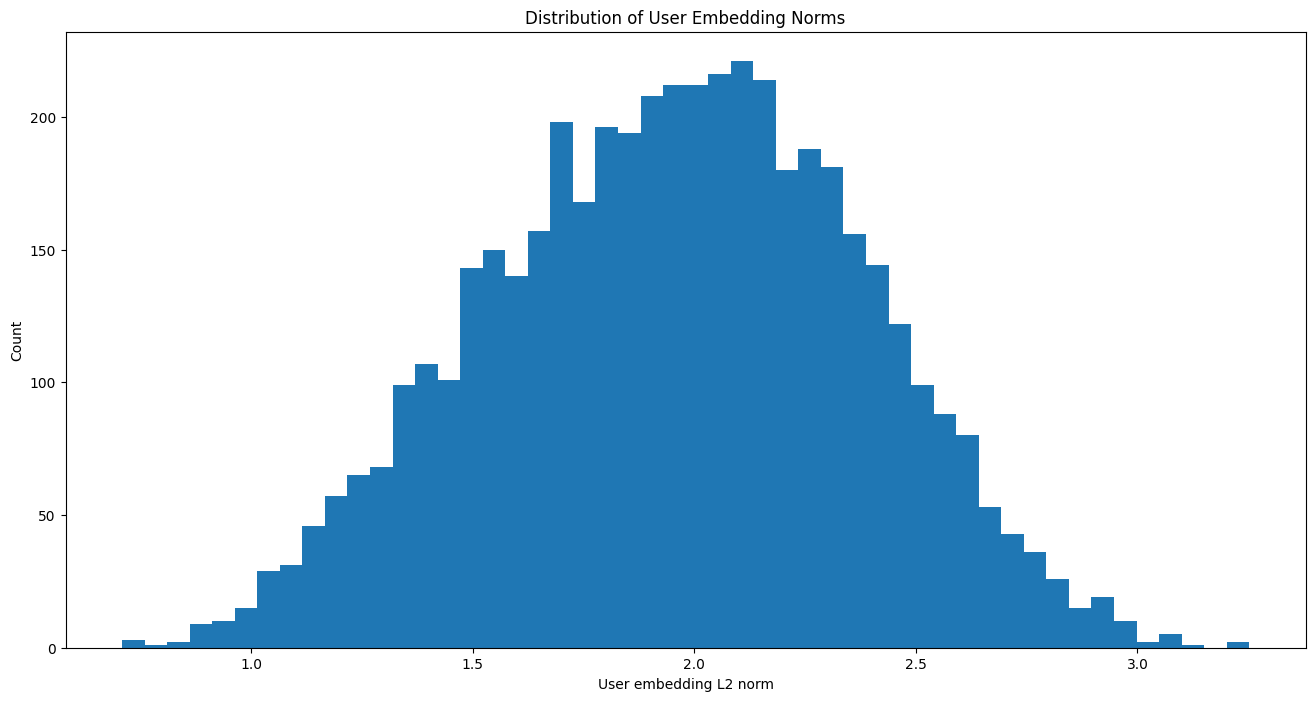

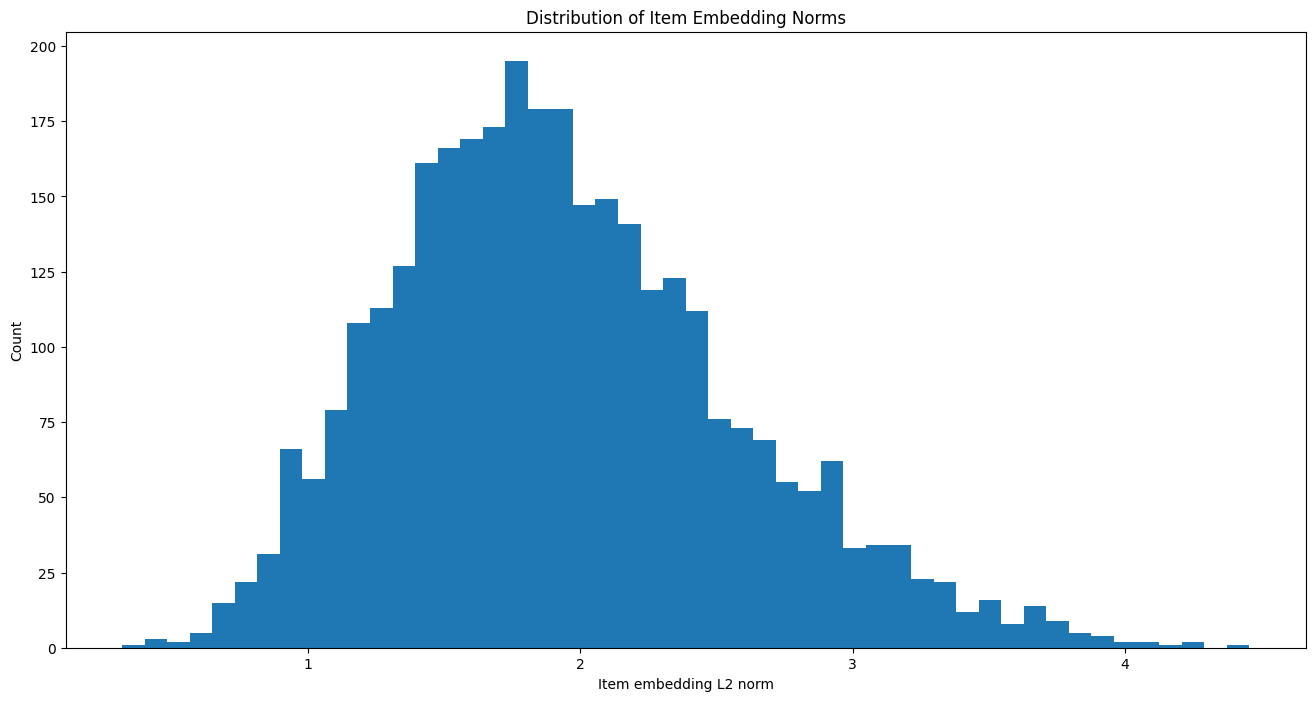

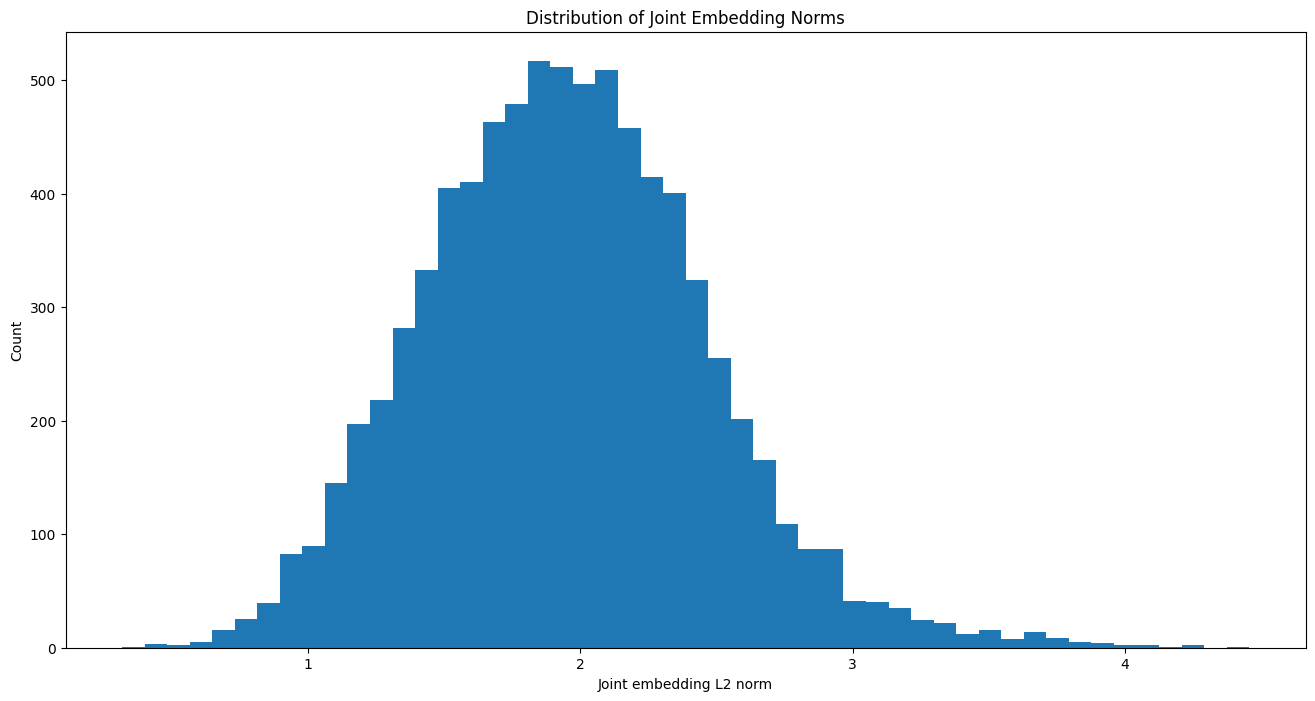

In [13]:
plt.figure(figsize=(16, 8))
plt.hist(user_norms, bins=50)
plt.xlabel("User embedding L2 norm")
plt.ylabel("Count")
plt.title("Distribution of User Embedding Norms")
plt.show()

plt.figure(figsize=(16, 8))
plt.hist(item_norms, bins=50)
plt.xlabel("Item embedding L2 norm")
plt.ylabel("Count")
plt.title("Distribution of Item Embedding Norms")
plt.show()

plt.figure(figsize=(16, 8))
plt.hist(joint_norms, bins=50)
plt.xlabel("Joint embedding L2 norm")
plt.ylabel("Count")
plt.title("Distribution of Joint Embedding Norms")
plt.show()

### 2.2 Per-dimension scale diagnostics

In [14]:
def make_dimension_summary(embedding_matrix, entity_name):
    dim_means = embedding_matrix.mean(axis=0)
    dim_stds = embedding_matrix.std(axis=0)
    dim_mins = embedding_matrix.min(axis=0)
    dim_maxs = embedding_matrix.max(axis=0)

    return {
        "entity": entity_name,
        "embedding_dim": embedding_matrix.shape[1],
        "mean_abs_dim_mean": float(np.mean(np.abs(dim_means))),
        "max_abs_dim_mean": float(np.max(np.abs(dim_means))),
        "mean_dim_std": float(np.mean(dim_stds)),
        "min_dim_std": float(np.min(dim_stds)),
        "max_dim_std": float(np.max(dim_stds)),
        "mean_dim_range": float(np.mean(dim_maxs - dim_mins)),
        "min_dim_range": float(np.min(dim_maxs - dim_mins)),
        "max_dim_range": float(np.max(dim_maxs - dim_mins)),
        "near_zero_std_dims": int((dim_stds < 1e-6).sum()),
    }


dimension_summary = pd.DataFrame([
    make_dimension_summary(user_embeddings_np, "users"),
    make_dimension_summary(item_embeddings_np, "items"),
    make_dimension_summary(joint_embeddings_np, "joint"),
])
display(dimension_summary.round(6))

,entity,embedding_dim,mean_abs_dim_mean,max_abs_dim_mean,mean_dim_std,min_dim_std,max_dim_std,mean_dim_range,min_dim_range,max_dim_range,near_zero_std_dims
0,users,64,0.130606,0.160811,0.207571,0.154444,0.284398,1.506842,1.201100,1.795356,0
1,items,64,0.043823,0.073481,0.249562,0.210715,0.315773,1.712607,1.249885,2.345136,0
2,joint,64,0.060107,0.077314,0.242861,0.205895,0.298848,1.728023,1.289855,2.345136,0


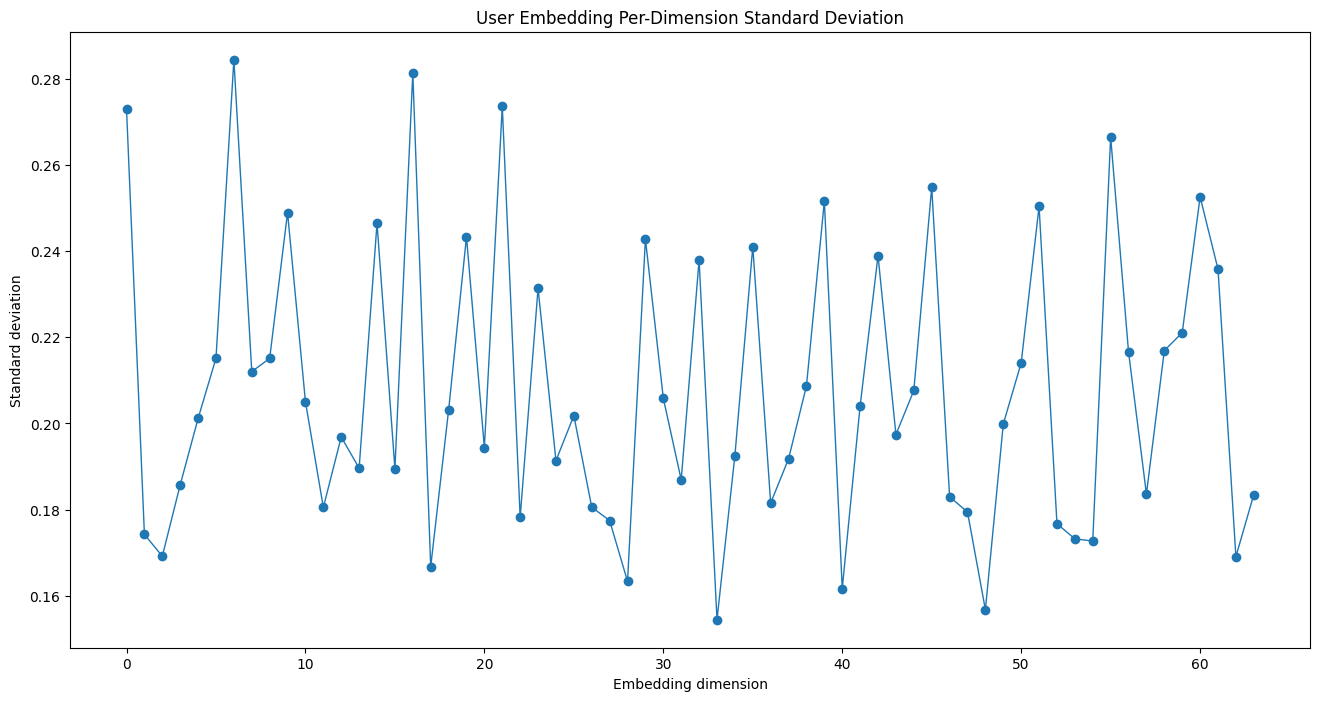

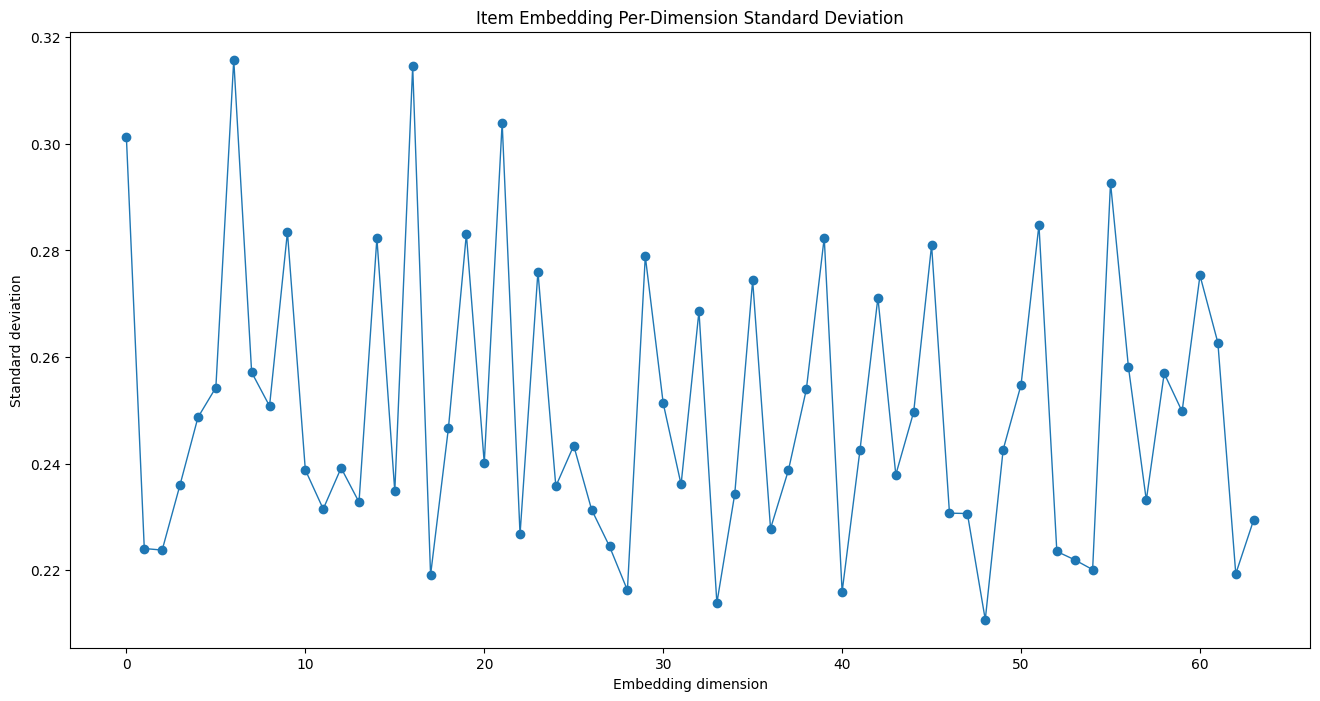

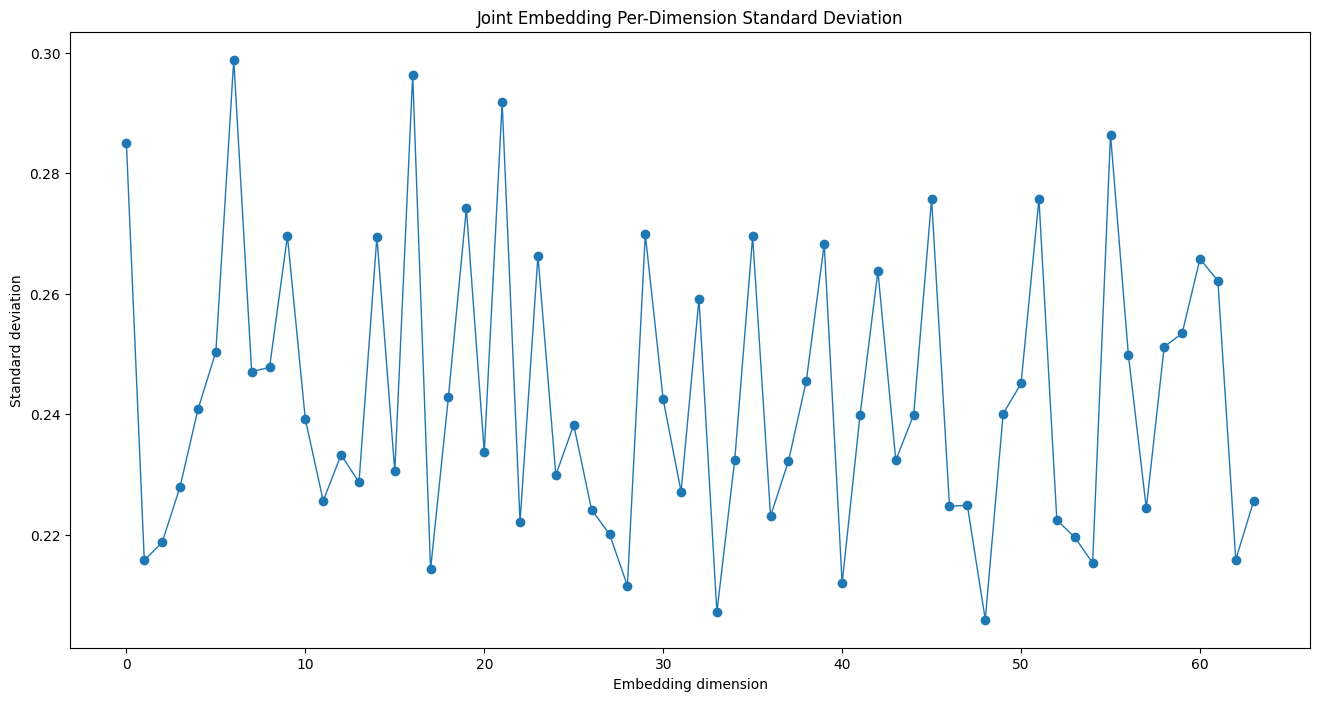

In [15]:
user_dim_stds = user_embeddings_np.std(axis=0)
item_dim_stds = item_embeddings_np.std(axis=0)
joint_dim_stds = joint_embeddings_np.std(axis=0)

plt.figure(figsize=(16, 8))
plt.plot(np.arange(len(user_dim_stds)), user_dim_stds, marker="o", linewidth=1)
plt.xlabel("Embedding dimension")
plt.ylabel("Standard deviation")
plt.title("User Embedding Per-Dimension Standard Deviation")
plt.show()

plt.figure(figsize=(16, 8))
plt.plot(np.arange(len(item_dim_stds)), item_dim_stds, marker="o", linewidth=1)
plt.xlabel("Embedding dimension")
plt.ylabel("Standard deviation")
plt.title("Item Embedding Per-Dimension Standard Deviation")
plt.show()

plt.figure(figsize=(16, 8))
plt.plot(np.arange(len(joint_dim_stds)), joint_dim_stds, marker="o", linewidth=1)
plt.xlabel("Embedding dimension")
plt.ylabel("Standard deviation")
plt.title("Joint Embedding Per-Dimension Standard Deviation")
plt.show()

### 2.3 Build candidate spaces for DBSCAN

In [16]:
user_embeddings_standardized = StandardScaler().fit_transform(user_embeddings_np)
item_embeddings_standardized = StandardScaler().fit_transform(item_embeddings_np)

# Important:
# Joint standardization is fitted on the combined user+item matrix.
# Do not stack separately standardized users/items, because that would put
# users and items on different artificial scales before computing joint distances.
joint_embeddings_standardized = StandardScaler().fit_transform(joint_embeddings_np)

user_embeddings_l2 = normalize(user_embeddings_np, norm="l2")
item_embeddings_l2 = normalize(item_embeddings_np, norm="l2")
joint_embeddings_l2 = normalize(joint_embeddings_np, norm="l2")

candidate_embedding_spaces = {
    "users_raw_euclidean": {
        "entity": "users",
        "space": "raw",
        "metric": "euclidean",
        "matrix": user_embeddings_np,
    },
    "users_standardized_euclidean": {
        "entity": "users",
        "space": "standardized",
        "metric": "euclidean",
        "matrix": user_embeddings_standardized,
    },
    "users_l2_cosine": {
        "entity": "users",
        "space": "l2_normalized",
        "metric": "cosine",
        "matrix": user_embeddings_l2,
    },
    "items_raw_euclidean": {
        "entity": "items",
        "space": "raw",
        "metric": "euclidean",
        "matrix": item_embeddings_np,
    },
    "items_standardized_euclidean": {
        "entity": "items",
        "space": "standardized",
        "metric": "euclidean",
        "matrix": item_embeddings_standardized,
    },
    "items_l2_cosine": {
        "entity": "items",
        "space": "l2_normalized",
        "metric": "cosine",
        "matrix": item_embeddings_l2,
    },
    "joint_raw_euclidean": {
        "entity": "joint",
        "space": "raw",
        "metric": "euclidean",
        "matrix": joint_embeddings_np,
    },
    "joint_standardized_euclidean": {
        "entity": "joint",
        "space": "standardized",
        "metric": "euclidean",
        "matrix": joint_embeddings_standardized,
    },
    "joint_l2_cosine": {
        "entity": "joint",
        "space": "l2_normalized",
        "metric": "cosine",
        "matrix": joint_embeddings_l2,
    },
}

candidate_space_summary = pd.DataFrame([
    {
        "space_name": space_name,
        "entity": spec["entity"],
        "space": spec["space"],
        "metric": spec["metric"],
        "rows": spec["matrix"].shape[0],
        "embedding_dim": spec["matrix"].shape[1],
        "finite_values": bool(np.isfinite(spec["matrix"]).all()),
    }
    for space_name, spec in candidate_embedding_spaces.items()
])
display(candidate_space_summary)

expected_candidate_rows = {
    "users": user_embeddings_np.shape[0],
    "items": item_embeddings_np.shape[0],
    "joint": joint_embeddings_np.shape[0],
}

expected_candidate_space_names = {
    "users_raw_euclidean",
    "users_standardized_euclidean",
    "users_l2_cosine",
    "items_raw_euclidean",
    "items_standardized_euclidean",
    "items_l2_cosine",
    "joint_raw_euclidean",
    "joint_standardized_euclidean",
    "joint_l2_cosine",
}

assert set(candidate_embedding_spaces.keys()) == expected_candidate_space_names
assert candidate_space_summary["finite_values"].all()
assert candidate_space_summary["embedding_dim"].nunique() == 1
assert candidate_space_summary["embedding_dim"].iloc[0] == user_embeddings_np.shape[1]

for _, row in candidate_space_summary.iterrows():
    assert row["rows"] == expected_candidate_rows[row["entity"]]

candidate_space_summary.to_parquet(
    step3_dir / "candidate_embedding_space_summary.parquet",
    index=False,
)

print("Candidate embedding spaces created successfully.")

,space_name,entity,space,metric,rows,embedding_dim,finite_values
0,users_raw_euclidean,users,raw,euclidean,4722,64,True
1,users_standardized_euclidean,users,standardized,euclidean,4722,64,True
2,users_l2_cosine,users,l2_normalized,cosine,4722,64,True
3,items_raw_euclidean,items,raw,euclidean,3250,64,True
4,items_standardized_euclidean,items,standardized,euclidean,3250,64,True
5,items_l2_cosine,items,l2_normalized,cosine,3250,64,True
6,joint_raw_euclidean,joint,raw,euclidean,7972,64,True
7,joint_standardized_euclidean,joint,standardized,euclidean,7972,64,True
8,joint_l2_cosine,joint,l2_normalized,cosine,7972,64,True


Candidate embedding spaces created successfully.


### 2.4 Compare distance distributions across spaces

In [17]:
def get_full_pairwise_distances(embedding_matrix, metric):
    """
    Compute all pairwise distances for the full embedding matrix
    and return only the upper triangle, excluding the diagonal.
    """
    distance_matrix = pairwise_distances(
        embedding_matrix,
        metric=metric,
    )

    upper_triangle = distance_matrix[
        np.triu_indices_from(distance_matrix, k=1)
    ]

    return upper_triangle


def full_distance_summary(
    embedding_matrix,
    entity,
    space,
    metric,
):
    n_embeddings = embedding_matrix.shape[0]

    upper_triangle = get_full_pairwise_distances(
        embedding_matrix=embedding_matrix,
        metric=metric,
    )

    return {
        "entity": entity,
        "space": space,
        "metric": metric,
        "n_embeddings": n_embeddings,
        "n_pairwise_distances": len(upper_triangle),
        "mean_distance": upper_triangle.mean(),
        "std_distance": upper_triangle.std(),
        "min_distance": upper_triangle.min(),
        "p01_distance": np.percentile(upper_triangle, 1),
        "p05_distance": np.percentile(upper_triangle, 5),
        "p10_distance": np.percentile(upper_triangle, 10),
        "median_distance": np.median(upper_triangle),
        "p90_distance": np.percentile(upper_triangle, 90),
        "p95_distance": np.percentile(upper_triangle, 95),
        "p99_distance": np.percentile(upper_triangle, 99),
        "max_distance": upper_triangle.max(),
    }


distance_summaries = []

for space_name, spec in candidate_embedding_spaces.items():
    distance_summaries.append(
        full_distance_summary(
            embedding_matrix=spec["matrix"],
            entity=spec["entity"],
            space=spec["space"],
            metric=spec["metric"],
        )
    )

distance_summary = pd.DataFrame(distance_summaries)

display(
    distance_summary
    .sort_values(["entity", "space", "metric"])
    .round(6)
)

expected_pairwise_distances = {
    "users": user_embeddings_np.shape[0] * (user_embeddings_np.shape[0] - 1) // 2,
    "items": item_embeddings_np.shape[0] * (item_embeddings_np.shape[0] - 1) // 2,
    "joint": joint_embeddings_np.shape[0] * (joint_embeddings_np.shape[0] - 1) // 2,
}

for _, row in distance_summary.iterrows():
    assert row["n_pairwise_distances"] == expected_pairwise_distances[row["entity"]]

distance_summary.to_parquet(
    step3_dir / "distance_summary_full.parquet",
    index=False,
)

full_distance_diagnostic_config = {
    "diagnostic_type": "full_pairwise_distance_distribution",
    "description": (
        "Distance diagnostics were computed using all available embeddings "
        "for each candidate user/item/joint space. This avoids sampling noise before "
        "selecting preprocessing, distance metric, and DBSCAN parameters."
    ),
}

with open(step3_dir / "distance_diagnostic_config.json", "w") as f:
    json.dump(full_distance_diagnostic_config, f, indent=2)

print("Saved full pairwise distance diagnostics to:", step3_dir)

,entity,space,metric,n_embeddings,n_pairwise_distances,mean_distance,std_distance,min_distance,p01_distance,p05_distance,p10_distance,median_distance,p90_distance,p95_distance,p99_distance,max_distance
5,items,l2_normalized,cosine,3250,5279625,0.962921,0.360519,0.012443,0.142175,0.309272,0.455112,0.984732,1.420218,1.528720,1.693059,1.973187
3,items,raw,euclidean,3250,5279625,2.710251,0.845584,0.414965,1.196010,1.503631,1.697565,2.610589,3.866821,4.250780,4.985378,7.656690
4,items,standardized,euclidean,3250,5279625,10.773815,3.458946,1.581359,4.661496,5.879344,6.653489,10.344804,15.504330,17.099163,20.191784,31.013597
8,joint,l2_normalized,cosine,7972,31772406,0.936994,0.371913,0.012443,0.223318,0.372731,0.469518,0.902782,1.468731,1.599346,1.771227,1.980394
6,joint,raw,euclidean,7972,31772406,2.660985,0.734929,0.366049,1.320669,1.616654,1.797485,2.571738,3.650166,4.026196,4.744189,7.656690
7,joint,standardized,euclidean,7972,31772406,10.877148,3.115081,1.496857,5.339428,6.543810,7.278382,10.450603,15.087211,16.749317,19.912945,31.786440
2,users,l2_normalized,cosine,4722,11146281,0.703811,0.250637,0.027139,0.207083,0.313847,0.384691,0.691728,1.035156,1.136507,1.332715,1.853371
0,users,raw,euclidean,4722,11146281,2.322658,0.511285,0.366049,1.277732,1.527414,1.677818,2.296862,3.001282,3.206972,3.593305,5.022194
1,users,standardized,euclidean,4722,11146281,11.049712,2.435356,1.778670,6.086014,7.275497,7.989968,10.920681,14.276924,15.263330,17.144089,25.624001


Saved full pairwise distance diagnostics to: results_step3_v2


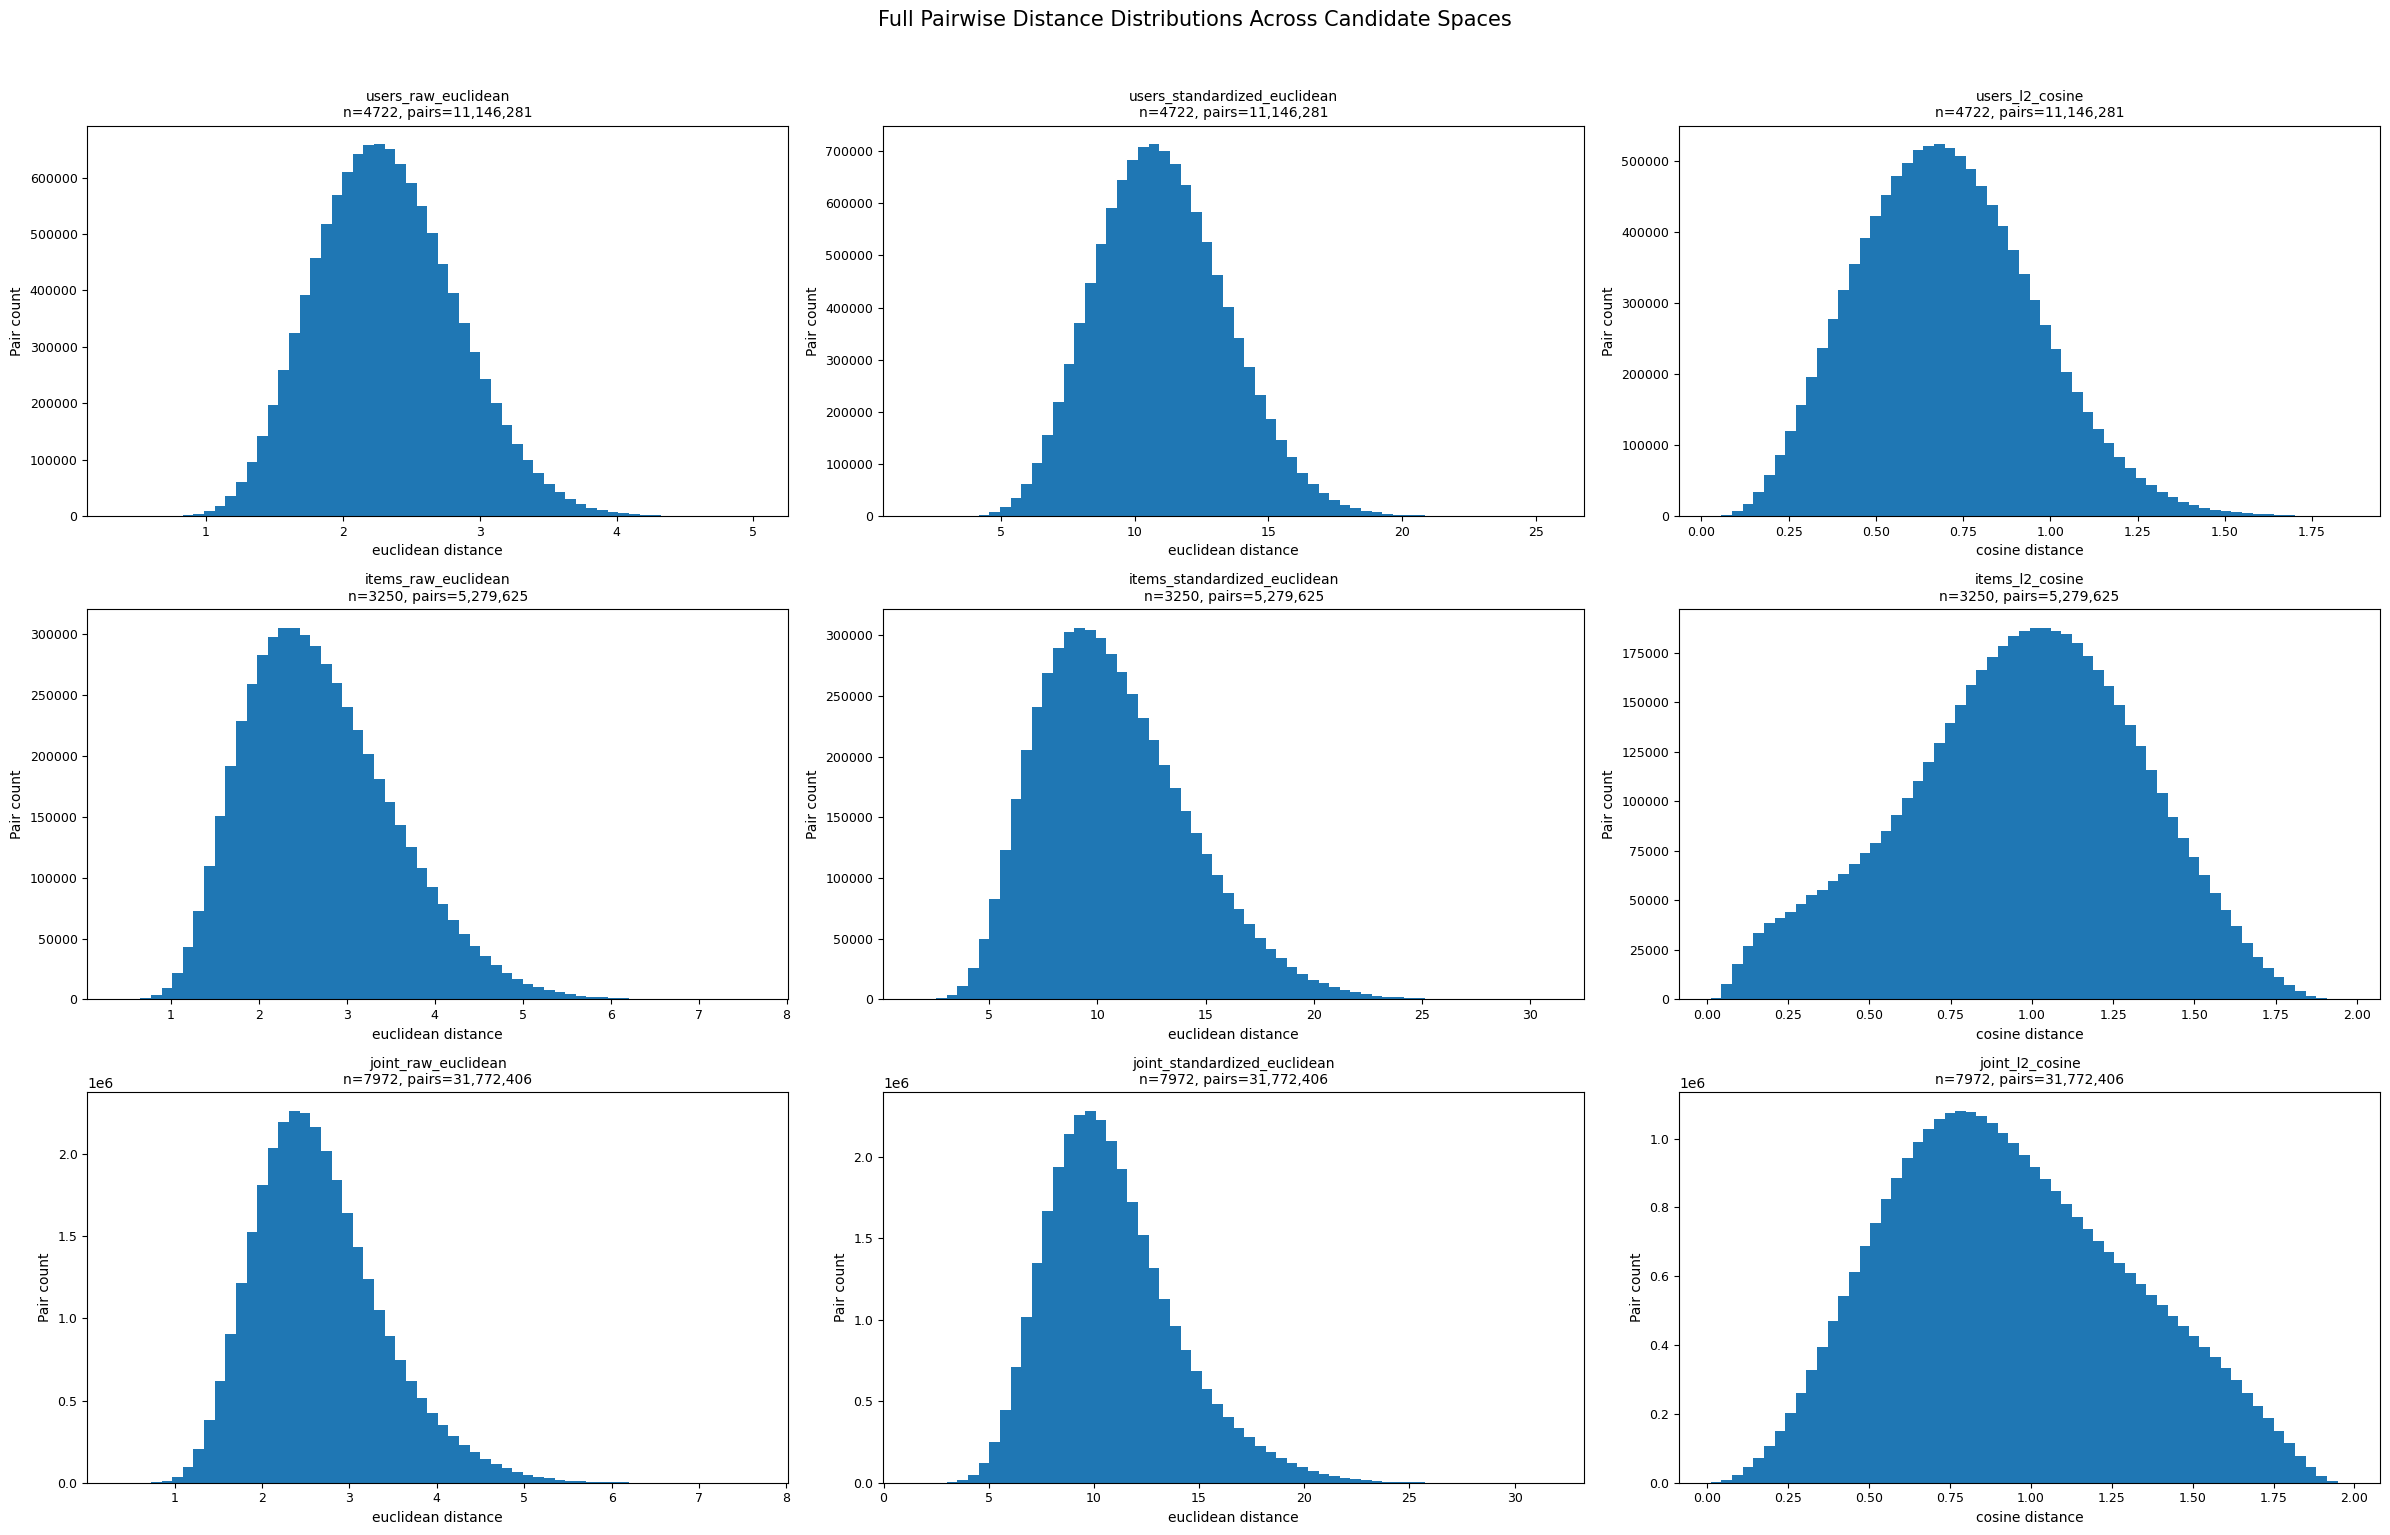

In [18]:
plot_space_names = list(candidate_embedding_spaces.keys())

ncols = 3
nrows = int(np.ceil(len(plot_space_names) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(24, 5 * nrows),
    squeeze=False,
)

axes = axes.reshape(-1)

for ax, space_name in zip(axes, plot_space_names):
    spec = candidate_embedding_spaces[space_name]

    upper_triangle = get_full_pairwise_distances(
        embedding_matrix=spec["matrix"],
        metric=spec["metric"],
    )

    ax.hist(upper_triangle, bins=60)
    ax.set_title(
        f"{space_name}\n"
        f"n={spec['matrix'].shape[0]}, pairs={len(upper_triangle):,}",
        fontsize=10,
    )
    ax.set_xlabel(f"{spec['metric']} distance")
    ax.set_ylabel("Pair count")
    ax.tick_params(axis="both", labelsize=9)

for ax in axes[len(plot_space_names):]:
    ax.axis("off")

fig.suptitle(
    "Full Pairwise Distance Distributions Across Candidate Spaces",
    fontsize=15,
    y=1.02,
)

plt.tight_layout()
plt.show()

# 3